## Predição de Preços de Imóveis com Machine Learning

Neste projeto, realizo uma análise completa do dataset "Flats Price" (origem: Kaggle), com o objetivo de prever o preço de imóveis com base em diversas características.  
https://www.kaggle.com/datasets/sumanbera19/flats-price-dataset

### Etapas do projeto:
1. Exploração e limpeza de dados
2. Feature engineering
3. Modelagem com algoritmos de regressão
4. Tuning e validação
5. Interpretação dos resultados
6. Conclusões e insights de negócio

In [1]:
# importando bibliotecas

import pandas as pd
import numpy as np
import csv
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import missingno as msno
import re
import math
from collections import Counter
import ast
from sklearn.impute import SimpleImputer

In [2]:
# importando dados da base do kaggle

df = pd.read_csv("../dados/flats - flats.csv")
df_raw = df
df.head(5)

,property_name,link,society,price,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,property_id
0,2 BHK Flat in Krishna Colony,https://www.99acres.com/2-bhk-bedroom-apartmen...,maa bhagwati residency,45 Lac,"₹ 5,000/sq.ft.",Carpet area: 900 (83.61 sq.m.),2 Bedrooms,2 Bathrooms,1 Balcony,NaN,"Krishna Colony, Gurgaon, Haryana",4th of 4 Floors,West,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Pear...",So with lift.Maa bhagwati residency is one of ...,"['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment4 out of 5', 'Safety4 out of 5', ...",C68850746
1,2 BHK Flat in Ashok Vihar,https://www.99acres.com/2-bhk-bedroom-apartmen...,Apna Enclave,50 Lac,"₹ 7,692/sq.ft.",Carpet area: 650 (60.39 sq.m.),2 Bedrooms,2 Bathrooms,1 Balcony,NaN,"46b, Ashok Vihar, Gurgaon, Haryana",1st of 3 Floors,West,10+ Year Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', ...","Property situated on main road, railway statio...","['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Ge...","['Security / Fire Alarm', 'Maintenance Staff',...","['Environment4 out of 5', 'Safety4 out of 5', ...",H68850564
2,2 BHK Flat in Sohna,https://www.99acres.com/2-bhk-bedroom-apartmen...,Tulsiani Easy in Homes,40 Lac,"₹ 6,722/sq.ft.",Carpet area: 595 (55.28 sq.m.),2 Bedrooms,2 Bathrooms,3 Balconies,NaN,"Sohna, Gurgaon, Haryana",12nd of 14 Floors,NaN,0 to 1 Year Old,"['Huda City Metro', 'Golf Course extn road', '...","This property is 15 km away from badshapur, gu...",NaN,"['Power Back-up', 'Feng Shui / Vaastu Complian...","['Environment4 out of 5', 'Safety4 out of 5', ...",J68850120
3,2 BHK Flat in Sector 61 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Smart World Orchard,1.47 Crore,"₹ 12,250/sq.ft.",Carpet area: 1200 (111.48 sq.m.),2 Bedrooms,2 Bathrooms,2 Balconies,Study Room,"Sector 61 Gurgaon, Gurgaon, Haryana",2nd of 4 Floors,NaN,Dec 2023,"['Sector 55-56 Metro station', 'Bestech Centra...",Near to metro station of sector 56 and opposit...,NaN,"['Security / Fire Alarm', 'Private Garden / Te...",NaN,S68849476
4,2 BHK Flat in Sector 92 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Parkwood Westend,70 Lac,"₹ 5,204/sq.ft.",Super Built up area 1345(124.95 sq.m.),2 Bedrooms,2 Bathrooms,3 Balconies,Study Room,"Sector 92 Gurgaon, Gurgaon, Haryana",5th of 8 Floors,NaN,Under Construction,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",We are the proud owners of this 2 bhk alongwit...,[],NaN,"['Environment5 out of 5', 'Safety3 out of 5', ...",L47956793


O objetivo nesta etapa é realizar uma exploração inicial da base de dados e, com auxílio do dicionário de variáveis, compreender os significados, características e tipos de cada feature.

In [3]:
df.shape

(3028, 20)

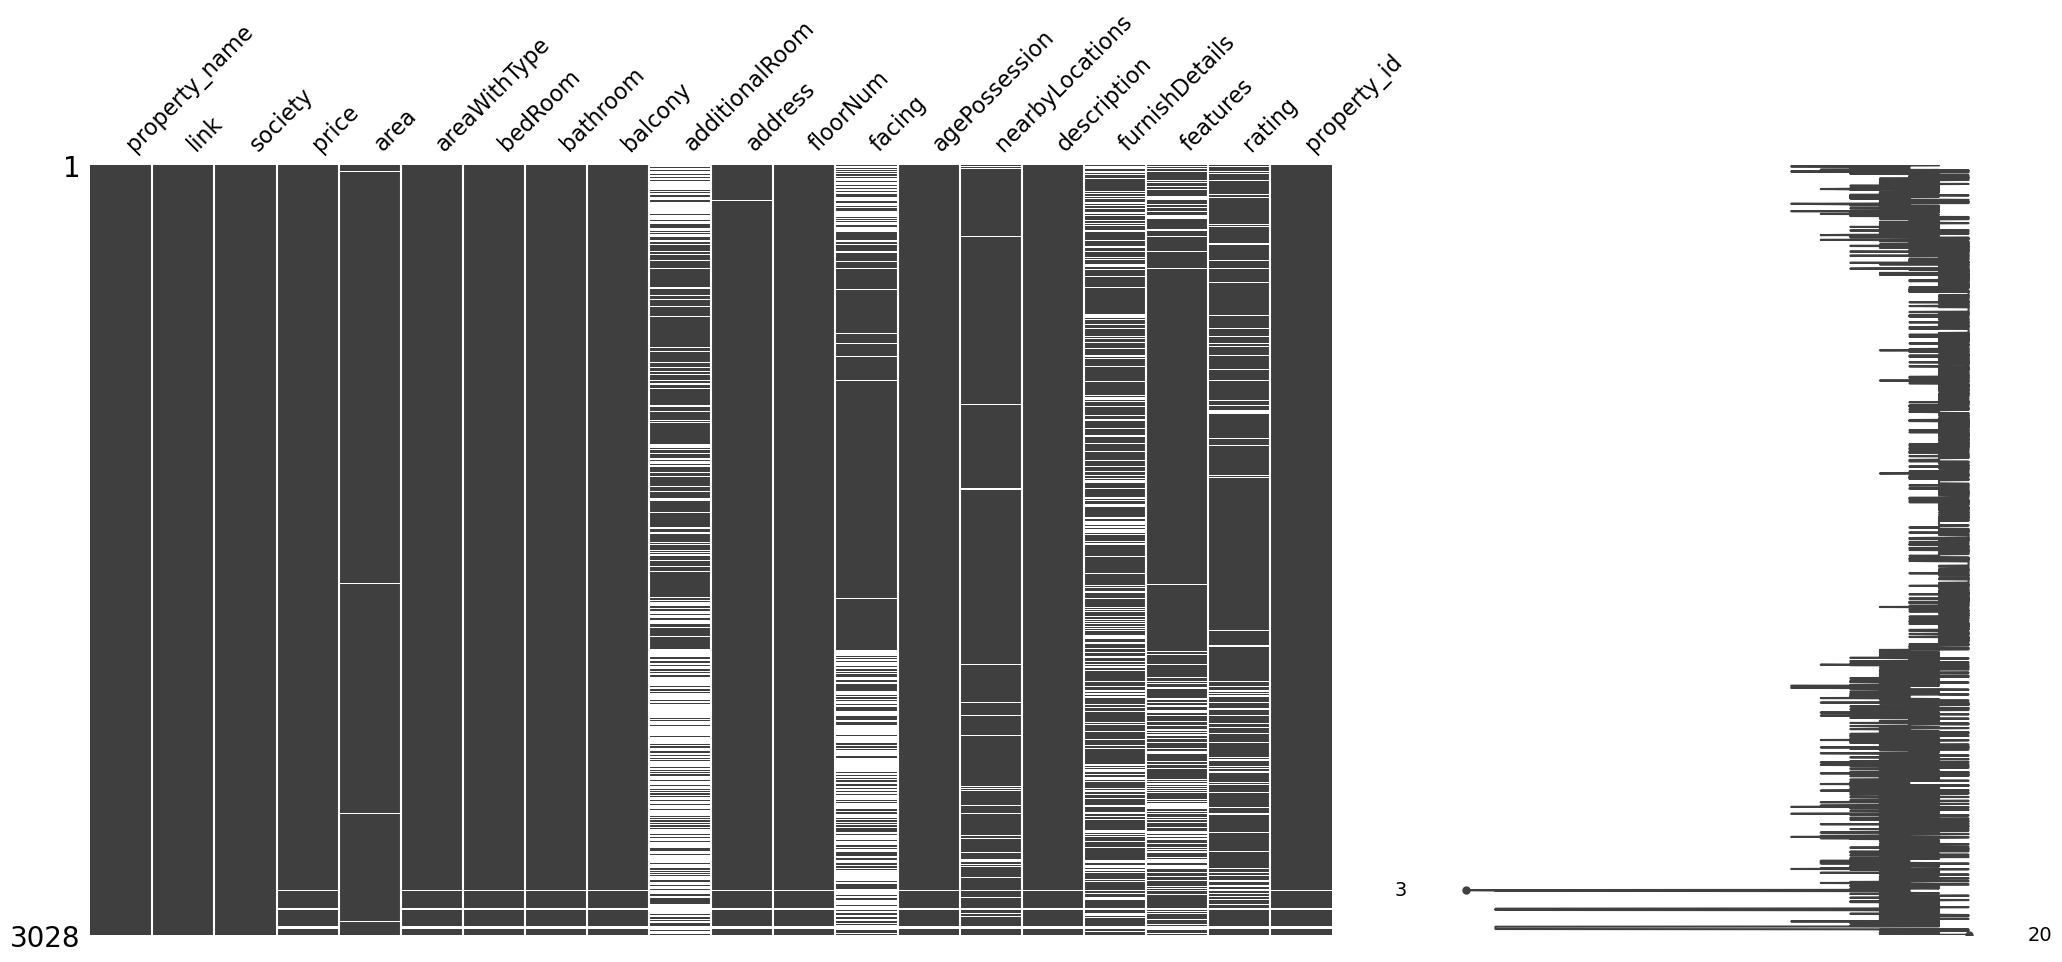

In [4]:
# visualizando missings

msno.matrix(df, width_ratios=(2,1))
plt.show()

In [5]:
# calculando a proporção de missing por coluna

missing_ratio = (df.isnull().sum() / df.shape[0]).sort_values(ascending=False)

print(missing_ratio)

additionalRoom     0.440225
facing             0.297226
furnishDetails     0.272127
features           0.142999
rating             0.115918
nearbyLocations    0.037649
address            0.008256
floorNum           0.006935
price              0.006605
agePossession      0.006605
description        0.006275
property_id        0.006275
balcony            0.006275
bathroom           0.006275
bedRoom            0.006275
areaWithType       0.006275
area               0.004293
society            0.000330
link               0.000000
property_name      0.000000
dtype: float64


A base de dados apresenta poucos valores faltantes, portanto, não irei realizar nenhum tratamento de missings aqui.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3028 entries, 0 to 3027
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   property_name    3028 non-null   object
 1   link             3028 non-null   object
 2   society          3027 non-null   object
 3   price            3008 non-null   object
 4   area             3015 non-null   object
 5   areaWithType     3009 non-null   object
 6   bedRoom          3009 non-null   object
 7   bathroom         3009 non-null   object
 8   balcony          3009 non-null   object
 9   additionalRoom   1695 non-null   object
 10  address          3003 non-null   object
 11  floorNum         3007 non-null   object
 12  facing           2128 non-null   object
 13  agePossession    3008 non-null   object
 14  nearbyLocations  2914 non-null   object
 15  description      3009 non-null   object
 16  furnishDetails   2204 non-null   object
 17  features         2595 non-null   

A base apresenta colunas com informações numéricas misturadas a texto, o que dificulta as análises e vai exigir uma limpeza nos dados.

In [7]:
df.head(2)

,property_name,link,society,price,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,property_id
0,2 BHK Flat in Krishna Colony,https://www.99acres.com/2-bhk-bedroom-apartmen...,maa bhagwati residency,45 Lac,"₹ 5,000/sq.ft.",Carpet area: 900 (83.61 sq.m.),2 Bedrooms,2 Bathrooms,1 Balcony,NaN,"Krishna Colony, Gurgaon, Haryana",4th of 4 Floors,West,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Pear...",So with lift.Maa bhagwati residency is one of ...,"['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment4 out of 5', 'Safety4 out of 5', ...",C68850746
1,2 BHK Flat in Ashok Vihar,https://www.99acres.com/2-bhk-bedroom-apartmen...,Apna Enclave,50 Lac,"₹ 7,692/sq.ft.",Carpet area: 650 (60.39 sq.m.),2 Bedrooms,2 Bathrooms,1 Balcony,NaN,"46b, Ashok Vihar, Gurgaon, Haryana",1st of 3 Floors,West,10+ Year Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', ...","Property situated on main road, railway statio...","['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Ge...","['Security / Fire Alarm', 'Maintenance Staff',...","['Environment4 out of 5', 'Safety4 out of 5', ...",H68850564


In [8]:
df['price'].unique()

array(['45 Lac', '50 Lac', '40 Lac', '1.47 Crore', '70 Lac', '41 Lac',
       '2 Crore', '1.8 Crore', '1.1 Crore', '4.75 Crore', '96 Lac',
       '29 Lac', '1.35 Crore', '95 Lac', '3.95 Crore', '90 Lac',
       '1.05 Crore', nan, '2.2 Crore', '1.01 Crore', '1.85 Crore',
       '86 Lac', '2.85 Crore', 'Price on Request', '42 Lac', '6.15 Crore',
       '6.25 Crore', '1.6 Crore', '3.25 Crore', '85 Lac', '75 Lac',
       '82 Lac', '29.99 Lac', '78 Lac', '74 Lac', '3.2 Crore',
       '1.3 Crore', '25 Lac', '1.99 Crore', '1.83 Crore', '2.25 Crore',
       '2.8 Crore', '83 Lac', '80 Lac', '1.25 Crore', '23 Lac', '30 Lac',
       '1.55 Crore', '79 Lac', '99 Lac', '1.9 Crore', '1 Crore',
       '2.5 Crore', '55 Lac', '65 Lac', '31.75 Lac', '93 Lac',
       '1.2 Crore', '56 Lac', '2.7 Crore', '1.45 Crore', '46 Lac',
       '4.5 Crore', '64 Lac', '28 Lac', '3.87 Crore', '1.38 Crore',
       '43 Lac', '28.5 Lac', '1.75 Crore', '2.1 Crore', '1.29 Crore',
       '1.65 Crore', '24 Lac', '31.5 Lac', '

Observando a variável `price`, é possível perceber que temos valores com o sufixo **"Lac"** e outras com o sufixo **"Crore"**, que representam diferentes escalas de valor.  

A conversão básica entre **Lakh (Lac)** e **Crore** no sistema indiano é: 

1 Crore = 100 Lakhs.  

Irei portanto, realizar o ajuste dos valores para manter a variável como numérica, deixando os valores na mesma unidade de medida **Lac**.

In [9]:
# Função para converter valores de 'price'

def convert_price_to_millions(price_str):
    if pd.isna(price_str):
        return None
    price_str = price_str.strip().lower()
    if 'lac' in price_str:
        value = float(re.findall(r"[\d.]+", price_str)[0])
        return value * 1  # Mantém
    elif 'crore' in price_str:
        value = float(re.findall(r"[\d.]+", price_str)[0])
        return value * 100   # 1 Crore = 100 Lakhs
    else:
        try:
            return float(re.findall(r"[\d.]+", price_str)[0])
        except:
            return None


# Aplicando no DataFrame
df['price'] = df['price'].apply(convert_price_to_millions)


Além da coluna `price`, outros exemplos são as colunas `bedRoom`, `bathroom` e `balcony`, onde os valores aparecem com textos, ao invés de conter apenas o valor numérico.

In [10]:
df[['bedRoom', 'bathroom', 'balcony']].head(5)

,bedRoom,bathroom,balcony
0,2 Bedrooms,2 Bathrooms,1 Balcony
1,2 Bedrooms,2 Bathrooms,1 Balcony
2,2 Bedrooms,2 Bathrooms,3 Balconies
3,2 Bedrooms,2 Bathrooms,2 Balconies
4,2 Bedrooms,2 Bathrooms,3 Balconies


In [11]:
# removendo textos e mantendo apenas números

df['bedRoom'] = df['bedRoom'].str.extract(r'(\d+)').astype(float)
df['bathroom'] = df['bathroom'].str.extract(r'(\d+)').astype(float)
df['balcony'] = df['balcony'].str.extract(r'(\d+)').astype(float)

In [12]:
df[['bedRoom', 'bathroom', 'balcony']].head(5)

,bedRoom,bathroom,balcony
0,2.0,2.0,1.0
1,2.0,2.0,1.0
2,2.0,2.0,3.0
3,2.0,2.0,2.0
4,2.0,2.0,3.0


Para a variável `areaWithType` irei realizar uma transformação para três novas variáveis, `area_type`, `area_sqft` e `area_sqm`.

In [13]:
df["areaWithType"].head(10)

0                       Carpet area: 900 (83.61 sq.m.)
1                       Carpet area: 650 (60.39 sq.m.)
2                       Carpet area: 595 (55.28 sq.m.)
3                     Carpet area: 1200 (111.48 sq.m.)
4               Super Built up area 1345(124.95 sq.m.)
5                     Built Up area: 654 (60.76 sq.m.)
6               Super Built up area 1500(139.35 sq.m.)
7                     Carpet area: 2290 (212.75 sq.m.)
8    Built Up area: 1350 (125.42 sq.m.)Carpet area:...
9                   Built Up area: 2813 (261.34 sq.m.)
Name: areaWithType, dtype: object

In [14]:
# tipo da área
df['area_type'] = df['areaWithType'].str.extract(r'^([A-Za-z\s]+)')

# área em sqft (primeiro número antes do parêntese)
df['area_sqft'] = df['areaWithType'].str.extract(r'(\d+(?:,\d{3})*)')
df['area_sqft'] = df['area_sqft'].str.replace(',', '', regex=False).astype(float)

# área em m² (número dentro dos parênteses)
df['area_sqm'] = df['areaWithType'].str.extract(r'\(([\d.]+) sq\.m\.\)')
df['area_sqm'] = df['area_sqm'].astype(float)

In [15]:
# excluindo a coluna 'suja'
df.drop(columns=['areaWithType'], inplace=True)
df.drop(columns=['area'], inplace=True)

In [16]:
df[['area_type', 'area_sqft', 'area_sqm']].head(5)

,area_type,area_sqft,area_sqm
0,Carpet area,900.0,83.61
1,Carpet area,650.0,60.39
2,Carpet area,595.0,55.28
3,Carpet area,1200.0,111.48
4,Super Built up area,1345.0,124.95


Para a variável `floorNum` irei transformar nas variáveis `floor` e `total_floors`.

In [17]:
df[['floorNum']].head(5)

,floorNum
0,4th of 4 Floors
1,1st of 3 Floors
2,12nd of 14 Floors
3,2nd of 4 Floors
4,5th of 8 Floors


In [18]:
# andar atual
df['floor'] = df['floorNum'].str.extract(r'(\d+)[a-z]{2,}')  # Ex: '4th', '1st'
df['floor'] = df['floor'].astype(float)

# total de andares
df['total_floors'] = df['floorNum'].str.extract(r'of\s+(\d+)\s+Floors')
df['total_floors'] = df['total_floors'].astype(float)

df.drop(columns=['floorNum'], inplace=True)

Irei também realizar um feature engineering para representar a posição relativa do imóvel dentro do prédio, em vez de usar apenas o número absoluto do andar, e outra para identificar se o imóvel está localizado em um prédio alto, definindo como critério edifícios com 15 ou mais andares.

In [19]:
def floor_category(row):
    if pd.isna(row["floor"]) or pd.isna(row["total_floors"]):
        return "unknown"
    
    ratio = row["floor"] / row["total_floors"]
    
    if ratio <= 0.33:
        return "low"
    elif ratio <= 0.66:
        return "mid"
    else:
        return "high"

df["floor_category"] = df.apply(floor_category, axis=1)

In [20]:
df["is_high_rise"] = (df["total_floors"] >= 15).astype(int)

In [21]:
df[['floor', 'total_floors', 'floor_category', 'is_high_rise']].head(5)

,floor,total_floors,floor_category,is_high_rise
0,4.0,4.0,high,0
1,1.0,3.0,mid,0
2,12.0,14.0,high,0
3,2.0,4.0,mid,0
4,5.0,8.0,mid,0


Avaliando a coluna `agePossession` irei aproveitar para realizar um feature engineering mais complexo de forma a não perder as informações contidas e estruturá-las de maneira eficiente.  

Pude perceber que existem informações como ranges que se referem ao tempo de existência do imóvel, como `"1 to 5 Year Old"`, mas também meses exatos como `"Dec 2023"` que se referem a datas futuras em que o imóvel será entregue. Além disso, isso nos evidencia que essa base de dados foi elaborada em meados de 2023, informação que não encontrei de forma explícita no dicionário no kaggle.

Portanto, irei criar novas features sendo elas:

- `construction_status`: imóveis prontos para morar `(ready)`, em obra, sem data certa `(under_construction)` e com data futura de entrega `(future_possession)`
- `0_to_1_years_old`: imóveis prontos dentro do range de 0 a 1 ano.
- `1_to_5_years_old`: imóveis prontos dentro do range de 1 a 5 anos.
- `5_to_10_years_old`: imóveis prontos dentro do range de 5 a 10 anos.
- `10_more_years_old`: imóveis prontos com 10 ou mais anos.
- `expected_possession_date`: data prevista de entrega do imóvel.



In [22]:
df['agePossession'].unique()

array(['1 to 5 Year Old', '10+ Year Old', '0 to 1 Year Old', 'Dec 2023',
       'Under Construction', 'undefined', 'Jun 2024', 'Mar 2024',
       'Dec 2025', 'By 2023', '5 to 10 Year Old', 'Sep 2025', 'Jan 2024',
       'Within 6 months', 'Jan 2027', 'Dec 2024', 'Oct 2024', 'Nov 2023',
       'Jul 2026', 'Feb 2024', 'Oct 2023', 'Jan 2025', 'Aug 2023', nan,
       'By 2024', 'Apr 2024', 'Nov 2025', 'agePossession', 'Dec 2026',
       'Within 3 months', 'Apr 2026', 'By 2025', 'Jul 2027', 'Sep 2023',
       'By 2027', 'Jan 2026', 'May 2024', 'Nov 2024', 'Aug 2024',
       'Jun 2027', 'Mar 2025', 'Jul 2024', 'Jul 2025', 'Sep 2027',
       'Jun 2025', 'Jan 2028', 'Aug 2026', 'Mar 2026', 'Aug 2025',
       'Oct 2025'], dtype=object)

In [23]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1479
0 to 1 Year Old        443
5 to 10 Year Old       361
undefined              222
10+ Year Old           137
Under Construction      92
Within 6 months         63
Within 3 months         25
Dec 2023                20
By 2023                 19
By 2024                 16
Dec 2024                15
Mar 2024                14
Aug 2023                 7
Oct 2024                 7
Dec 2025                 7
Jan 2024                 7
Nov 2023                 5
Jun 2024                 5
Aug 2024                 5
By 2025                  4
Sep 2023                 4
Jan 2025                 4
Jul 2024                 4
Oct 2023                 3
Feb 2024                 3
Nov 2024                 3
May 2024                 3
Aug 2025                 2
Jan 2026                 2
Mar 2025                 2
Jun 2027                 2
Jul 2025                 2
Oct 2025                 2
Jul 2027                 2
Apr 2026                 2
Dec 2026      

In [24]:
df['construction_status'] = df['agePossession'].apply(
    lambda x: 'ready' if 'Year Old' in str(x) else (
        'under_construction' if 'Under Construction' in str(x) else 'future_possession'
    )
)

In [25]:
df['age_0_to_1'] = df['agePossession'].str.contains('0 to 1', na=False).astype(int)
df['age_1_to_5'] = df['agePossession'].str.contains('1 to 5', na=False).astype(int)
df['age_5_to_10'] = df['agePossession'].str.contains('5 to 10', na=False).astype(int)
df['age_10_plus'] = df['agePossession'].str.contains('10\\+', na=False).astype(int)

In [26]:
# Apenas se construction_status == 'future_possession'
df['expected_possession_date'] = pd.to_datetime(
    df['agePossession'], format='%b %Y', errors='coerce'
)

df.drop(columns=['agePossession'], inplace=True)

In [27]:
df[['age_0_to_1', 'age_1_to_5', 'age_5_to_10', 'age_10_plus', 'expected_possession_date']].head(5)

,age_0_to_1,age_1_to_5,age_5_to_10,age_10_plus,expected_possession_date
0,0,1,0,0,NaT
1,0,0,0,1,NaT
2,1,0,0,0,NaT
3,0,0,0,0,2023-12-01
4,0,0,0,0,NaT


Para a variável `address` irei extrair a informação do setor (sector) e também realizar um one-hot encoding para região, informações que podem ser de grande valor.

In [28]:
df["address"].head(10)

0                     Krishna Colony, Gurgaon, Haryana
1                   46b, Ashok Vihar, Gurgaon, Haryana
2                              Sohna, Gurgaon, Haryana
3                  Sector 61 Gurgaon, Gurgaon, Haryana
4                  Sector 92 Gurgaon, Gurgaon, Haryana
5    Sohna Sector 36, Sector 36 Gurgaon, Gurgaon, H...
6          Dwarka Expressway Gurgaon, Gurgaon, Haryana
7                 Sector 104 Gurgaon, Gurgaon, Haryana
8           H 23, Sector 88B Gurgaon, Gurgaon, Haryana
9                  Sector 78 Gurgaon, Gurgaon, Haryana
Name: address, dtype: object

In [29]:
def extract_sector(text):
    match = re.search(r"sector\s*(\d+)", str(text).lower())
    return int(match.group(1)) if match else None

df["sector_number"] = df["address"].apply(extract_sector)

In [30]:
df["sector_number"].isna().mean()

0.14663143989431968

In [31]:
df["address_clean"] = df["address"].str.lower().fillna("")

In [32]:
regions = [
    "gurgaon",
    "gurugram",
    "delhi",
    "dwarka",
    "manesar"
]

for region in regions:
    df[f"loc_{region}"] = df["address_clean"].apply(
        lambda x: int(region in x)
    )

In [33]:
df[[f"loc_{r}" for r in regions]].sum().sort_values(ascending=False)

loc_gurgaon     3002
loc_manesar       30
loc_dwarka        29
loc_delhi         22
loc_gurugram       2
dtype: int64

In [34]:
df.drop(columns=['address', 'address_clean'], inplace=True)

In [35]:
df[['sector_number', 'loc_gurgaon', 'loc_manesar', 'loc_dwarka', 'loc_delhi', 'loc_gurugram']].head(5)

,sector_number,loc_gurgaon,loc_manesar,loc_dwarka,loc_delhi,loc_gurugram
0,NaN,1,0,0,0,0
1,NaN,1,0,0,0,0
2,NaN,1,0,0,0,0
3,61.0,1,0,0,0,0
4,92.0,1,0,0,0,0


Continuando com o tratamento dos dados, vamos agora para a variável `nearbyLocations`

In [36]:
df['nearbyLocations'].head(5)

0    ['Chintapurni Mandir', 'State bank ATM', 'Pear...
1    ['Chintapurni Mandir', 'Sheetla Mata Mandir', ...
2    ['Huda City Metro', 'Golf Course extn road', '...
3    ['Sector 55-56 Metro station', 'Bestech Centra...
4    ['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...
Name: nearbyLocations, dtype: object

Essa coluna possui bastante potencial escondido, uma vez que os locais próximos podem influenciar diretamente o valor (preço) do imóvel.  
Quero realizar um feature engineering que considere locais que ao meu ver são relevantes, para isso, vou verificar na base se há a presença de algumas palavras específicas.

In [37]:
# junta textos
texto_total_nl = " ".join(df["nearbyLocations"].dropna().astype(str)).lower()

# remove pontuação
texto_total_nl = re.sub(r"[^\w\s]", "", texto_total_nl)

# separa palavras
palavras_nl = texto_total_nl.split()

# remove stopwords
stopwords_nl = {
    "a", "an", "the",
    "and", "or", "but",
    "in", "on", "at", "to", "for", "of", "with",
    "by", "from", "as",
    "is", "are", "was", "were", "be", "been", "being",
    "this", "that", "these", "those",
    "it", "its",
    "he", "she", "they", "them", "his", "her", "their",
    "you", "your", "we", "our",
    "not", "no"
}

palavras_filtradas_nl = [p for p in palavras_nl if p not in stopwords_nl]

# conta
contador_nl = Counter(palavras_filtradas_nl)

In [38]:
df_freq_nl = pd.DataFrame(contador_nl.most_common(51), columns=["palavra", "frequencia"])
print(df_freq_nl)
df_freq_nl.size

          palavra  frequencia
0        hospital        5135
1            bank        3377
2         gurgaon        2980
3          school        2868
4          sector        2112
5         station        2066
6          clinic        1991
7   international        1898
8            park        1865
9         airport        1815
10           road        1641
11           mall        1606
12            atm        1551
13         gandhi        1523
14         indira        1514
15         centre        1300
16          metro        1277
17     university        1104
18       gurugram        1041
19         dwarka        1034
20             dr         992
21     expressway         982
22           golf         956
23           hdfc         856
24        railway         808
25          sohna         798
26         dental         724
27         public         702
28         course         631
29          delhi         630
30      institute         608
31             rd         607
32        

102

In [39]:
# transformando a coluna em formato de lista
def parse_locations(loc_str):
    try:
        return ast.literal_eval(loc_str)
    except:
        return []

df["parsed_locations"] = df["nearbyLocations"].apply(parse_locations)

# lista das palavras escolhidas
palavras = [
    "hospital", "bank", "gurgaon", "school", "sector", "station",
    "clinic", "international", "park", "airport", "road", "mall",
    "atm", "gandhi", "indira", "centre", "metro", "university",
    "gurugram", "dwarka", "dr", "expressway", "golf", "hdfc",
    "railway", "sohna", "dental", "public", "course", "delhi",
    "institute", "rd", "manesar", "india", "trampoline", "skyjumper",
    "icici", "petrol", "inn", "pump", "care", "hotel", "huda",
    "technology", "dpg", "mandir", "business", "imt", "intl",
    "state", "maternity"
]

# cria variáveis binárias
for palavra in palavras:
    col_name = f"has_{palavra}"

    df[col_name] = df["parsed_locations"].apply(
        lambda locs: int(
            any(
                palavra in str(loc).lower()
                for loc in locs
            )
        )
    )

In [40]:
df.drop(columns=['nearbyLocations', 'parsed_locations'], inplace=True)

Para a coluna `features` vou realizar algo próxima do feature engineering feito para `nearbyLocations`, considerando a presença de itens, facilidades e atributos do imóvel/prédio.

In [41]:
# junta textos
texto_total_f = " ".join(df["features"].dropna().astype(str)).lower()

# remove pontuação
texto_total_f = re.sub(r"[^\w\s]", "", texto_total_f)

# separa palavras
palavras_f = texto_total_f.split()

# remove stopwords
stopwords_f = {
    "a", "an", "the",
    "and", "or", "but",
    "in", "on", "at", "to", "for", "of", "with",
    "by", "from", "as",
    "is", "are", "was", "were", "be", "been", "being",
    "this", "that", "these", "those",
    "it", "its",
    "he", "she", "they", "them", "his", "her", "their",
    "you", "your", "we", "our",
    "not", "no"
}

palavras_filtradas_f = [p for p in palavras_f if p not in stopwords_f]

# conta
contador_f = Counter(palavras_filtradas_f)

In [42]:
df_freq_f = pd.DataFrame(contador_f.most_common(51), columns=["palavra", "frequencia"])
print(df_freq_f)
df_freq_f.size

         palavra  frequencia
0          water        4865
1         centre        3173
2       security        3111
3          lifts        2460
4           park        2437
5    maintenance        2190
6          staff        2190
7       intercom        2060
8       facility        2060
9        visitor        1933
10       parking        1933
11          fire        1828
12         alarm        1828
13       storage        1811
14       fitness        1735
15           gym        1735
16          club        1702
17         house        1702
18     community        1702
19        center        1702
20          feng        1693
21          shui        1693
22        vaastu        1693
23     compliant        1693
24      swimming        1662
25          pool        1662
26       ceiling        1562
27      shopping        1438
28          rain        1415
29    harvesting        1415
30     personnel        1283
31         waste        1071
32      disposal        1071
33  internetwi

102

In [43]:
# transformando a coluna em lista
def parse_features(loc_str):
    try:
        return ast.literal_eval(loc_str)
    except:
        return []

df["parsed_features"] = df["features"].apply(parse_features)

# categorias mais úteis para modelagem
keywords = {
    "has_water": ["water"],
    "has_security": ["security", "intercom", "alarm", "visitor"],
    "has_lift": ["lifts"],
    "has_park": ["park"],
    "has_maintenance": ["maintenance", "staff", "personnel"],
    "has_facility": ["facility"],
    "has_parking": ["parking"],
    "has_fire_safety": ["fire", "alarm"],
    "has_storage": ["storage"],
    "has_gym_fitness": ["fitness", "gym"],
    "has_club_house": ["club", "house", "community", "center", "centre"],
    "has_feng_shui": ["feng", "shui", "vaastu", "compliant"],
    "has_swimming_pool": ["swimming", "pool"],
    "has_shopping": ["shopping"],
    "has_rain_harvesting": ["rain", "harvesting"],
    "has_waste_disposal": ["waste", "disposal"],
    "has_internet": ["internetwifi", "connectivity"],
    "has_natural_light": ["natural", "light", "airy"],
    "has_water_treatment": ["softening", "plant"],
    "has_drainage": ["drainage"],
    "has_large_rooms": ["rooms", "room"],
    "has_piped_gas": ["pipedgas"],
    "has_high_ceiling": ["high", "height", "ceiling"],
    "has_separate_servant_entry": ["separate", "entry", "servant"]
}

# cria variáveis binárias
for col_name, kw_list in keywords.items():
    patterns = [re.compile(rf"\b{re.escape(k)}\b") for k in kw_list]

    df[col_name] = df["parsed_features"].apply(
        lambda locs: int(
            any(
                any(pattern.search(str(loc).lower()) for pattern in patterns)
                for loc in locs
            )
        )
    )

In [44]:
df.drop(columns=['features', 'parsed_features'], inplace=True)

Agora sim, após um feature engineering estruturado, irei seguir para algumas outras análises do dataset.

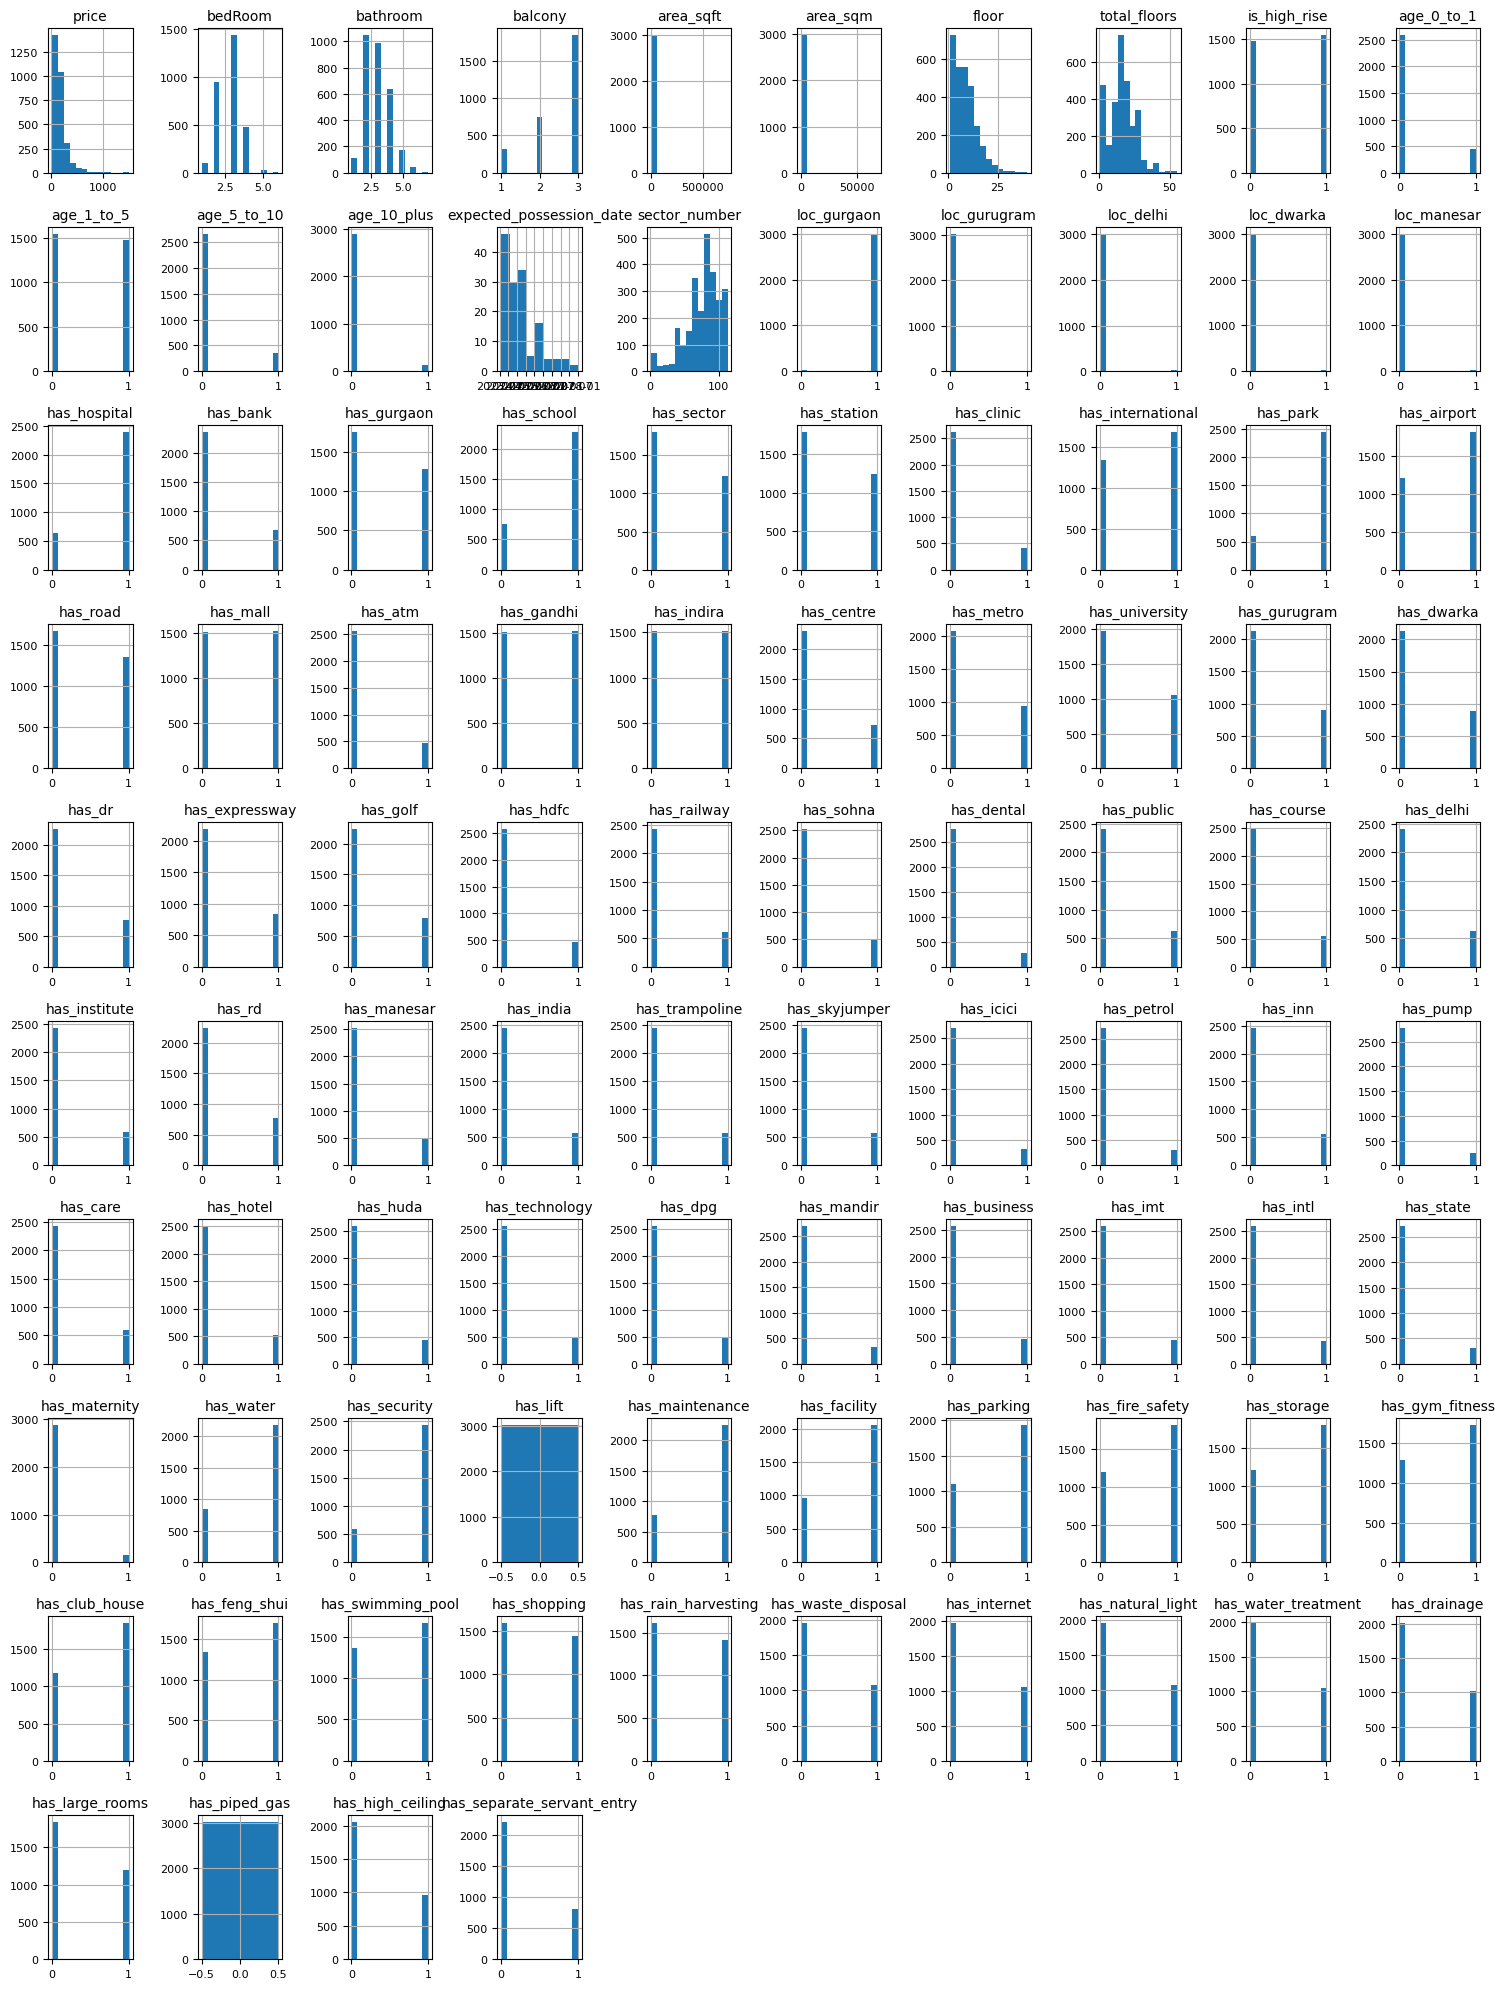

In [45]:
axes = df.hist(bins='sturges', figsize=(15, 20))

for ax in axes.ravel():
    ax.title.set_fontsize(10)
    ax.xaxis.label.set_fontsize(9)
    ax.yaxis.label.set_fontsize(9)
    ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

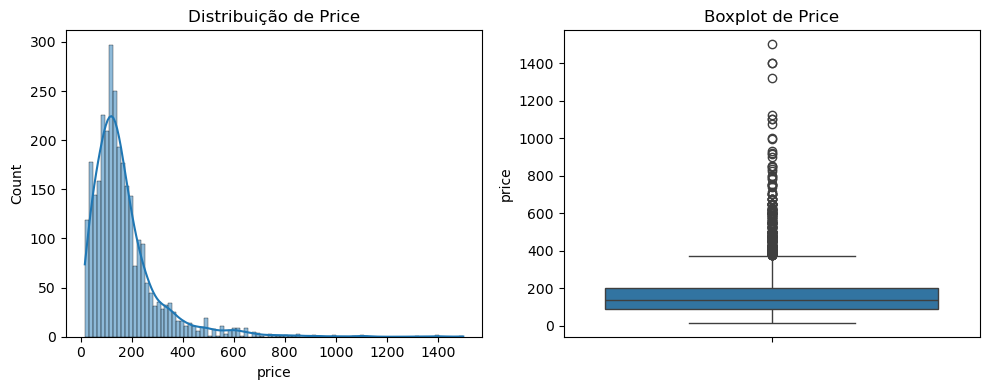

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histograma + KDE
sns.histplot(df["price"], kde=True, ax=axes[0])
axes[0].set_title("Distribuição de Price")

# Boxplot
sns.boxplot(y=df["price"], ax=axes[1])
axes[1].set_title("Boxplot de Price")

plt.tight_layout()
plt.show()

In [47]:
df['price'].describe()

count    2996.000000
mean      170.728495
std       139.862476
min        16.000000
25%        90.000000
50%       137.000000
75%       203.000000
max      1500.000000
Name: price, dtype: float64

Pode-se concluir que:

- A média (170,72 Lac) é superior à mediana (137,00 Lac), indicando uma distribuição assimétrica à direita (right-skewed).
- Isso sugere a presença de outliers de alto valor, ou seja, imóveis muito caros que elevam a média.
- O valor máximo (1500 Lac) reforça essa hipótese, estando muito distante das medidas centrais.
- O desvio padrão elevado (~140 Lac) indica alta dispersão dos preços, sugerindo um mercado heterogêneo.

Agora, irei desenvolver uma matriz de correlação para compreender como as variáveis se correlacionam entre si.

Devido ao alto número de colunas geradas, vou filtrar apenas as correlações mais relevantes com a variável target `Price` de forma a gerar uma matriz que possa ser analisada de forma mais eficiente.

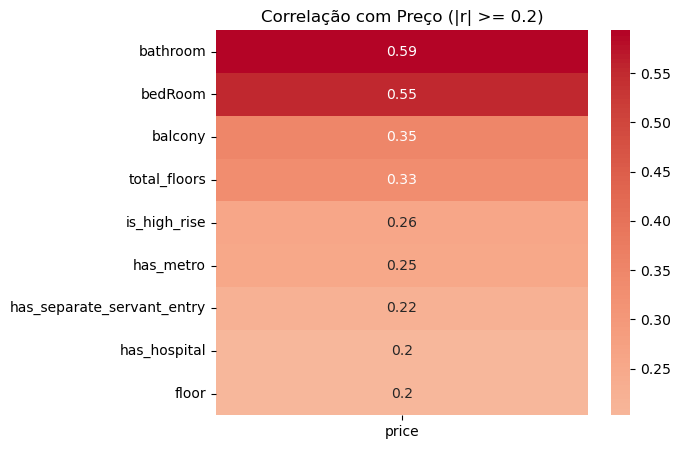

In [50]:
# só numéricas
df_numeric = df.select_dtypes(include="number")

# correlação com alvo
target = "price"
corr = df_numeric.corr()

# pega correlação com o target
target_corr = corr[target].dropna().sort_values(ascending=False)

# filtra só correlações fortes
threshold = 0.2
target_corr_strong = target_corr[abs(target_corr) >= threshold]

# remove o próprio target
target_corr_strong = target_corr_strong.drop(target)

# plot
plt.figure(figsize=(6, 5))

sns.heatmap(
    target_corr_strong.to_frame(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlação com Preço (|r| >= 0.2)")
plt.show()

Vale ressaltar que, mesmo com correlações individuais moderadas, o modelo pode ter alto poder preditivo quando combinamos múltiplas variáveis.

Como ponto de partida, elaborei algumas hipóteses com base em percepções iniciais e conhecimento prévio sobre o mercado imobiliário, com o objetivo de investigá-las e validá-las por meio dos dados. A matriz de correlação já trouxe uma percepção muito melhor a respeito de como as variáveis correlacionam entre si, porém, ainda irei confirmar mais a fundo tais hipóteses.


______

**Hipótese 01: quanto maior o número de banheiros, maior o preço do imóvel.**

/var/folders/0d/t9kyj1l518q1g2xczfj_w61m0000gn/T/ipykernel_74941/1037392300.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bathroom',


<Axes: xlabel='bathroom', ylabel='price'>

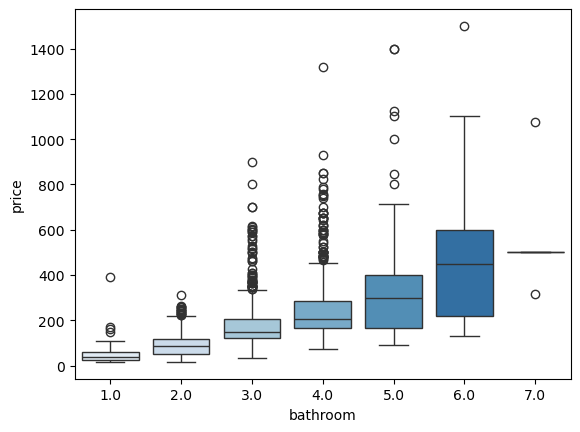

In [51]:
sns.boxplot(x='bathroom', 
            y='price',
            data=df,
            palette='Blues')

Conclusão: existe uma relação positiva clara entre o número de banheiros e o preço dos imóveis. No entanto, à medida que o número de banheiros aumenta, a variabilidade dos preços também cresce, indicando maior heterogeneidade nos imóveis de alto padrão.

______

**Hipótese 02: quanto maior o número de quartos, maior o preço do imóvel.**

/var/folders/0d/t9kyj1l518q1g2xczfj_w61m0000gn/T/ipykernel_74941/2973045297.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bedRoom',


<Axes: xlabel='bedRoom', ylabel='price'>

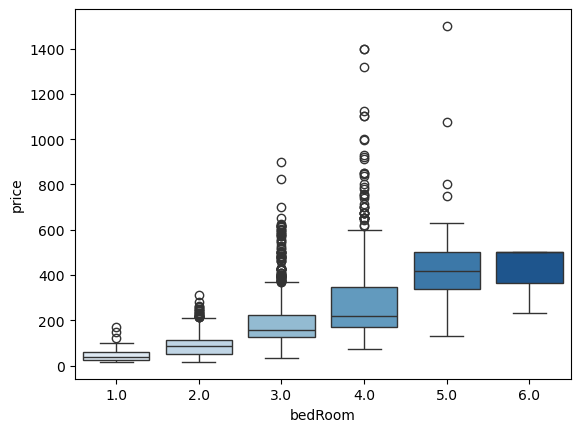

In [52]:
sns.boxplot(x='bedRoom', 
            y='price',
            data=df,
            palette='Blues')

Conclusão: a mediana do preço aumenta consistentemente conforme o número de quartos sobe de 1 para 6. Existe uma relação positiva clara entre número de quartos e preço.

______

**Hipótese 3: Proximidade a metrô aumenta preço**

/var/folders/0d/t9kyj1l518q1g2xczfj_w61m0000gn/T/ipykernel_74941/2987378366.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='has_metro',


<Axes: xlabel='has_metro', ylabel='price'>

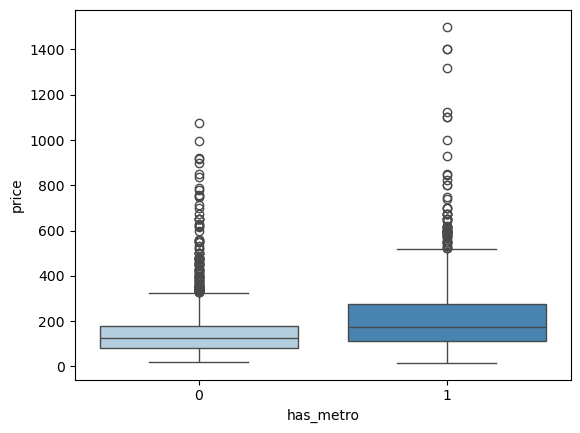

In [53]:
sns.boxplot(x='has_metro', 
            y='price',
            data=df,
            palette='Blues')

Conclusão: imóveis localizados próximos a estações de metrô apresentam, em média, preços mais elevados. No entanto, há uma grande sobreposição entre os grupos, indicando que, embora a proximidade ao metrô seja um fator relevante de valorização, ela não é determinante isoladamente e deve ser analisada em conjunto com outras características do imóvel.

______

**Hipótese 4: Quanto maior o número de andares do edifício, maior o preço do imóvel**

/var/folders/0d/t9kyj1l518q1g2xczfj_w61m0000gn/T/ipykernel_74941/1223995483.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='total_floors',


<Axes: xlabel='total_floors', ylabel='price'>

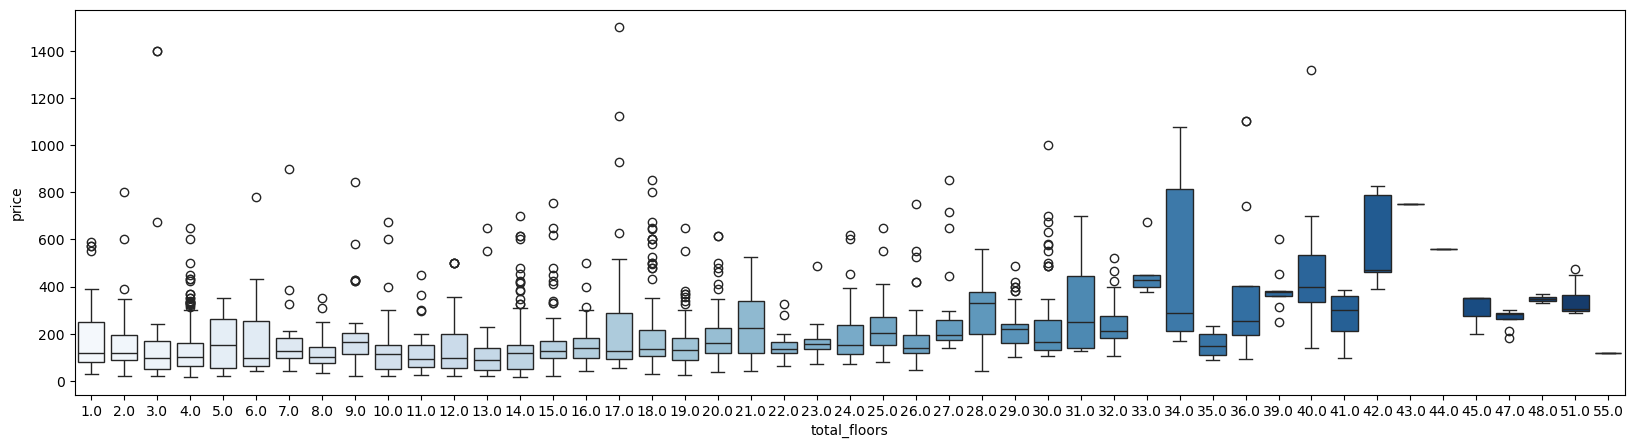

In [54]:
# Criar figura
plt.figure(figsize=(20, 5))

sns.boxplot(x='total_floors',
            y='price',
            data=df,
            palette='Blues')

Conclusão: a análise indica que há uma tendência positiva entre o número de andares e o preço dos imóveis, porém essa relação não é linear. Observa-se uma grande variabilidade de preços dentro de cada nível, sugerindo que o andar, isoladamente, não é um forte preditor de preço. A valorização se torna mais evidente em andares mais altos, especialmente acima de determinado patamar, indicando que a altura pode estar associada a imóveis de maior padrão, mas deve ser analisada em conjunto com outras variáveis.

______

## Modelo de Regressão

Agora, irei partir para um modelo de regressão que faça a predição do valor `(price)` do imóvel.

In [55]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [56]:
df.to_csv("imoveis_tratado.csv", index=False)

In [57]:
df.head(4)

,property_name,link,society,price,bedRoom,bathroom,balcony,additionalRoom,facing,description,...,has_rain_harvesting,has_waste_disposal,has_internet,has_natural_light,has_water_treatment,has_drainage,has_large_rooms,has_piped_gas,has_high_ceiling,has_separate_servant_entry
0,2 BHK Flat in Krishna Colony,https://www.99acres.com/2-bhk-bedroom-apartmen...,maa bhagwati residency,45.0,2.0,2.0,1.0,NaN,West,So with lift.Maa bhagwati residency is one of ...,...,0,0,0,0,0,0,0,0,0,0
1,2 BHK Flat in Ashok Vihar,https://www.99acres.com/2-bhk-bedroom-apartmen...,Apna Enclave,50.0,2.0,2.0,1.0,NaN,West,"Property situated on main road, railway statio...",...,0,0,0,0,0,0,0,0,0,0
2,2 BHK Flat in Sohna,https://www.99acres.com/2-bhk-bedroom-apartmen...,Tulsiani Easy in Homes,40.0,2.0,2.0,3.0,NaN,NaN,"This property is 15 km away from badshapur, gu...",...,0,0,0,0,0,0,0,0,0,0
3,2 BHK Flat in Sector 61 Gurgaon,https://www.99acres.com/2-bhk-bedroom-apartmen...,Smart World Orchard,147.0,2.0,2.0,2.0,Study Room,NaN,Near to metro station of sector 56 and opposit...,...,0,0,0,1,1,0,1,0,1,0


In [58]:
print("Variáveis categóricas:")
print(df.select_dtypes(include='object').columns)

Variáveis categóricas:
Index(['property_name', 'link', 'society', 'additionalRoom', 'facing',
       'description', 'furnishDetails', 'rating', 'property_id', 'area_type',
       'floor_category', 'construction_status'],
      dtype='object')


In [59]:
# Remove colunas irrelevantes
remove_columns = [
    'property_name', 'link', 'society', 'description',
    'additionalRoom', 'furnishDetails', 'rating', 'property_id', 'expected_possession_date'
]

# Criar df_model
df_model = df.drop(columns=remove_columns)

# elimina linhas nulas em price
df_model = df_model[df_model['price'].notnull()]

# Aplica one-hot encoding
df_model = pd.get_dummies(df_model, drop_first=True)

# Converte todas as colunas bool para int
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)


In [60]:
df_model.head(2)

,price,bedRoom,bathroom,balcony,area_sqft,area_sqm,floor,total_floors,is_high_rise,age_0_to_1,...,facing_South-East,facing_South-West,facing_West,area_type_Carpet area,area_type_Super Built up area,floor_category_low,floor_category_mid,floor_category_unknown,construction_status_ready,construction_status_under_construction
0,45.0,2.0,2.0,1.0,900.0,83.61,4.0,4.0,0,0,...,0,0,1,1,0,0,0,0,1,0
1,50.0,2.0,2.0,1.0,650.0,60.39,1.0,3.0,0,0,...,0,0,1,1,0,0,1,0,1,0


In [61]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2996 entries, 0 to 3027
Columns: 107 entries, price to construction_status_under_construction
dtypes: float64(9), int64(98)
memory usage: 2.5 MB


In [62]:
# Separa X e Y em variáveis independentes e target
X = df_model.drop(columns=['price'])
Y = df_model['price']

# Verificar shapes
print("Shape de X:", X.shape)
print("Shape de y:", Y.shape)

Shape de X: (2996, 106)
Shape de y: (2996,)


In [63]:
# aplicando transformação logarítmica na variável 'price' devido a assimetria
y_log = np.log1p(Y)

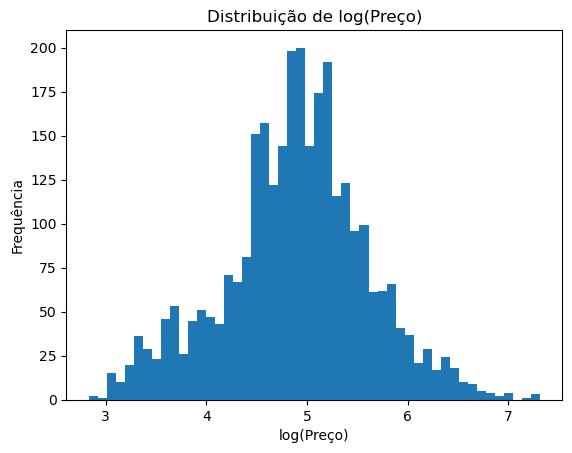

In [64]:
plt.hist(y_log, bins=50)
plt.title("Distribuição de log(Preço)")
plt.xlabel("log(Preço)")
plt.ylabel("Frequência")
plt.show()

Com a transformação logarítmica, ainda há concentração no início da escala, porém a cauda direita está muito mais suavizada. Foi possível, portanto, reduzir a assimetria da distruibuição original visando uma previsão proporcionalmente mais adequada.  
Dessa forma, durante o treno, vou usar y_log = `np.log1p(price)` e na predição final `np.expm1()`.

In [65]:
#verificando valores ausentes
print(X.isnull().sum().sort_values(ascending=False).head(10))

sector_number      423
floor              142
balcony             97
area_sqm            23
total_floors         2
bedRoom              0
has_parking          0
has_lift             0
has_maintenance      0
has_facility         0
dtype: int64


Aqui, irei tratar os valores nulos para realizar posteriormente a divisão em treino, teste e validação.

In [66]:
# Imputações específicas
X['floor'] = X['floor'].fillna(-1)  # Andar desconhecido
X['balcony'] = X['balcony'].fillna(0)  # Sem varanda
X['total_floors'] = X['total_floors'].fillna(X['total_floors'].median())

X = X.fillna(0)

In [67]:
# Dividindo a base em treino, teste e validação.

# Separa entre treino (70%) e temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y_log, test_size=0.3, random_state=42)

# Divide temp entre validação (15%) e teste (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)


Treino: (2097, 106)
Validação: (449, 106)
Teste: (450, 106)


In [68]:
# Criando uma tabela para armazenar as métricas de cada modelo
model_results = pd.DataFrame(columns=["Modelo", "Versão", "Conjunto", "RMSE", "MAE", "R2", "Notas"])

# Criando uma função para armazenar as métricas para cada modelo
def results_register(modelo, versao, conjunto, rmse, mae, r2, notas="-"):
    global model_results
    new_result = {
        "Modelo": modelo,
        "Versão": versao,
        "Conjunto": conjunto,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2),
        "R2": round(r2, 3),
        "Notas": notas
    }
    model_results = pd.concat([model_results, pd.DataFrame([new_result])], ignore_index=True)

### Regressão Linear

In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Treinar modelo
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

# 2. Prever na base de validação
y_pred_val = modelo_lr.predict(X_val)

# 3. Reverter o log para valores reais
y_val_real = np.expm1(y_val)
y_pred_real = np.expm1(y_pred_val)

# 4. Avaliar desempenho
mask = np.isfinite(y_pred_real)

rmse = np.sqrt(mean_squared_error(y_val_real[mask], y_pred_real[mask]))
mae = mean_absolute_error(y_val_real[mask], y_pred_real[mask])
r2 = r2_score(y_val_real[mask], y_pred_real[mask])

results_register("Linear Regression", "default", "validação", rmse, mae, r2)

/var/folders/0d/t9kyj1l518q1g2xczfj_w61m0000gn/T/ipykernel_74941/1095433212.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_results = pd.concat([model_results, pd.DataFrame([new_result])], ignore_index=True)


In [70]:
model_results

,Modelo,Versão,Conjunto,RMSE,MAE,R2,Notas
0,Linear Regression,default,validação,94.64,55.7,0.552,-


### regressão ridge

In [71]:
from sklearn.linear_model import Ridge

modelo_ridge = Ridge(alpha=10.0)
modelo_ridge.fit(X_train, y_train)

y_pred_val_ridge = modelo_ridge.predict(X_val)

# Reverter log
y_pred_real_ridge = np.expm1(y_pred_val_ridge)
mask = np.isfinite(y_pred_real_ridge)

# Avaliação
rmse = np.sqrt(mean_squared_error(y_val_real[mask], y_pred_real_ridge[mask]))
mae = mean_absolute_error(y_val_real[mask], y_pred_real_ridge[mask])
r2 = r2_score(y_val_real[mask], y_pred_real_ridge[mask])

results_register("Ridge Regression", "default", "validação", rmse, mae, r2)

In [72]:
model_results

,Modelo,Versão,Conjunto,RMSE,MAE,R2,Notas
0,Linear Regression,default,validação,94.64,55.70,0.552,-
1,Ridge Regression,default,validação,94.22,55.23,0.556,-


### Floresta Aleatória

In [73]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

y_pred_val_rf = modelo_rf.predict(X_val)
y_pred_real_rf = np.expm1(y_pred_val_rf)

# Avaliar
mask = np.isfinite(y_pred_real_rf)
rmse = np.sqrt(mean_squared_error(y_val_real[mask], y_pred_real_rf[mask]))
mae = mean_absolute_error(y_val_real[mask], y_pred_real_rf[mask])
r2 = r2_score(y_val_real[mask], y_pred_real_rf[mask])

results_register("Random Forest", "default", "validação", rmse, mae, r2)


In [74]:
model_results

,Modelo,Versão,Conjunto,RMSE,MAE,R2,Notas
0,Linear Regression,default,validação,94.64,55.70,0.552,-
1,Ridge Regression,default,validação,94.22,55.23,0.556,-
2,Random Forest,default,validação,59.73,23.67,0.821,-


### Gradient Boosting

In [75]:
from sklearn.ensemble import HistGradientBoostingRegressor

modelo_hgb = HistGradientBoostingRegressor(random_state=42)
modelo_hgb.fit(X_train, y_train)

y_pred_val_hgb = modelo_hgb.predict(X_val)
y_pred_real_hgb = np.expm1(y_pred_val_hgb)

mask = np.isfinite(y_pred_real_hgb)
rmse = np.sqrt(mean_squared_error(y_val_real[mask], y_pred_real_hgb[mask]))
mae = mean_absolute_error(y_val_real[mask], y_pred_real_hgb[mask])
r2 = r2_score(y_val_real[mask], y_pred_real_hgb[mask])

results_register("Gradient Boosting", "default", "validação", rmse, mae, r2)


In [76]:
model_results

,Modelo,Versão,Conjunto,RMSE,MAE,R2,Notas
0,Linear Regression,default,validação,94.64,55.70,0.552,-
1,Ridge Regression,default,validação,94.22,55.23,0.556,-
2,Random Forest,default,validação,59.73,23.67,0.821,-
3,Gradient Boosting,default,validação,59.73,25.54,0.821,-


Após a aplicação dos modelos e as primeiras métricas, podemos tirar alguns insights:

A regressão linear apresentou métricas fracas com alto erro. A Ridge por sua vez melhorou ligeiramente comparando com a linear, porém ainda longe do ideal.  
A floresta aleatória sim, apresentou um bom desempenho e o Gradient boosting o melhor desempenho geral, sendo o melhor modelo até aqui.

### Tuning dos modelos:

Agora irei realizar o tunning dos hiperparâmetros dos dois modelos que melhor performaram, `Random Forest` e `Gradient Boosting` na tentativa de alcançar métricas ainda melhores.

### Random Forest Tunning:

Parâmetros a serem trabalhados:

- `n_estimators`: Número de árvores na floresta;
- `max_depth`: Profundidade máxima das árvores;
- `min_samples_split`: Mínimo de amostras para dividir um nó;
- `min_samples_leaf`: Mínimo de amostras por folha;
- `max_features`: Quantidade de features consideradas por split.

In [77]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint

param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(5, 30),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", "log2"]
}

# Modelo base
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=50,  # número de combinações testadas
    cv=3,
    scoring="neg_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit no conjunto de treino
random_search.fit(X_train, y_train)

# Melhor modelo encontrado
melhor_modelo_rf = random_search.best_estimator_
melhores_parametros = random_search.best_params_


Fitting 3 folds for each of 50 candidates, totalling 150 fits


/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [78]:
# Prever no conjunto de validação
y_pred_val_rf = melhor_modelo_rf.predict(X_val)

# Reverter o log para valores reais
y_val_real = np.expm1(y_val)
y_pred_val_real = np.expm1(y_pred_val_rf)

# Tratar valores infinitos
mask = np.isfinite(y_pred_val_real)

# Calcular métricas
rmse = np.sqrt(mean_squared_error(y_val_real[mask], y_pred_val_real[mask]))
mae = mean_absolute_error(y_val_real[mask], y_pred_val_real[mask])
r2 = r2_score(y_val_real[mask], y_pred_val_real[mask])

In [79]:
results_register("Random Forest", "tunned", "validação", rmse, mae, r2)

### Gradient Boosting Tunning:

Parâmetros a serem trabalhados:

In [80]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Definir o modelo base
gb = GradientBoostingRegressor()

# Hiperparâmetros a testar
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

# Grid Search com validação cruzada
grid_search = GridSearchCV(estimator=gb, param_grid=param_grid,
                           scoring='neg_root_mean_squared_error',
                           cv=5, n_jobs=-1, verbose=1)

# Treinar
grid_search.fit(X_train, y_train)

# Melhor modelo
best_model = grid_search.best_estimator_

# Prever no conjunto de validação
y_pred = best_model.predict(X_val)

# Reverter log
y_pred_real = np.expm1(y_pred)
y_val_real = np.expm1(y_val)

# Avaliação
mask = np.isfinite(y_pred_real)
rmse = mean_squared_error(y_val_real[mask], y_pred_real[mask], squared=False)
mae = mean_absolute_error(y_val_real[mask], y_pred_real[mask])
r2 = r2_score(y_val_real[mask], y_pred_real[mask])

results_register("Gradient Boosting", "tunned", "validação", rmse, mae, r2)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [81]:
model_results

,Modelo,Versão,Conjunto,RMSE,MAE,R2,Notas
0,Linear Regression,default,validação,94.64,55.70,0.552,-
1,Ridge Regression,default,validação,94.22,55.23,0.556,-
2,Random Forest,default,validação,59.73,23.67,0.821,-
3,Gradient Boosting,default,validação,59.73,25.54,0.821,-
4,Random Forest,tunned,validação,72.87,30.80,0.734,-
5,Gradient Boosting,tunned,validação,55.95,23.05,0.843,-


Durante a etapa de ajuste de hiperparâmetros, foi aplicado tuning tanto nos modelos Random Forest quanto Gradient Boosting, utilizando validação cruzada (GridSearchCV). O objetivo era melhorar o desempenho dos modelos identificados como mais promissores na fase inicial.

Diante disso, a decisão é seguir com o modelo Gradient Boosting Tunned, que apresentou o melhor desempenho geral.

Agora, vou aplicar o modelo para a base de teste.

In [82]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Previsão no conjunto de teste com Gradient Boosting (modelo default)
y_pred_test = best_model.predict(X_test)

# Reverter log dos valores
y_test_real = np.expm1(y_test)
y_pred_test_real = np.expm1(y_pred_test)

# Remover valores não finitos (por segurança)
mask = np.isfinite(y_pred_test_real)

# Calcular métricas
rmse = np.sqrt(mean_squared_error(y_test_real[mask], y_pred_test_real[mask]))
mae = mean_absolute_error(y_test_real[mask], y_pred_test_real[mask])
r2 = r2_score(y_test_real[mask], y_pred_test_real[mask])

# Registrar os resultados
results_register("Gradient Boosting", "tunned", "teste", rmse, mae, r2)


In [83]:
model_results

,Modelo,Versão,Conjunto,RMSE,MAE,R2,Notas
0,Linear Regression,default,validação,94.64,55.70,0.552,-
1,Ridge Regression,default,validação,94.22,55.23,0.556,-
2,Random Forest,default,validação,59.73,23.67,0.821,-
3,Gradient Boosting,default,validação,59.73,25.54,0.821,-
4,Random Forest,tunned,validação,72.87,30.80,0.734,-
5,Gradient Boosting,tunned,validação,55.95,23.05,0.843,-
6,Gradient Boosting,tunned,teste,35.56,19.91,0.932,-


Aplicando ao conjunto de teste, a conclusão é de que o modelo ainda generaliza bem no teste e o MAE continua dentro de uma margem aceitável para o erro de precificação.  
Houve uma queda do R², que pode indicar uma leve variabilidade entre o conjunto de validação e o de teste.

### Analisando a importância das variáveis

In [84]:
importancias = best_model.feature_importances_

nomes_features = X_train.columns

df_importancias = pd.DataFrame({
    "Feature": nomes_features,
    "Importância": importancias
})

df_importancias = df_importancias.sort_values(by="Importância", ascending=False)

df_importancias.head(20)


,Feature,Importância
4,area_sqm,0.529250
1,bathroom,0.144946
3,area_sqft,0.076543
12,sector_number,0.063310
6,total_floors,0.034718
40,has_golf,0.014049
0,bedRoom,0.011446
2,balcony,0.006063
104,construction_status_ready,0.005871
54,has_icici,0.005752


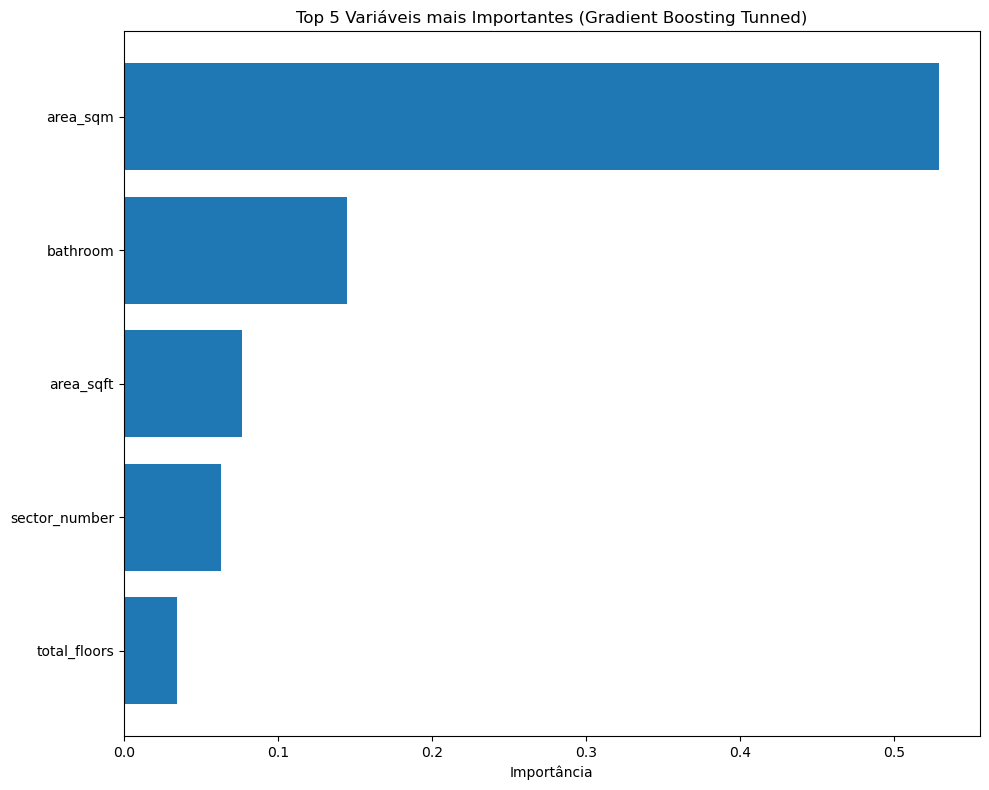

In [85]:
plt.figure(figsize=(10, 8))
plt.barh(df_importancias.head(5)['Feature'][::-1], df_importancias.head(5)['Importância'][::-1])
plt.xlabel("Importância")
plt.title("Top 5 Variáveis mais Importantes (Gradient Boosting Tunned)")
plt.tight_layout()
plt.show()


A área domina completamente a previsão, o que indica que o modelo está se baseando fortemente no tamanho do imóvel para prever o preço.

Apesar da baixa correlação linear entre a área e o preço, o modelo identificou essa variável como altamente relevante. Isso indica que a relação entre área e preço não é linear e depende de outras variáveis.

### Conclusão

Neste projeto, foram avaliados diferentes modelos de regressão para prever o preço de imóveis, partindo de abordagens lineares até modelos baseados em ensemble.

Os modelos lineares (Linear Regression e Ridge) apresentaram desempenho limitado (R² ≈ 0.55), indicando dificuldade em capturar relações não lineares presentes nos dados.

Em contraste, os modelos baseados em árvores (Random Forest e Gradient Boosting) apresentaram ganhos significativos, com R² acima de 0.82 no conjunto de validação, evidenciando maior capacidade de modelar interações complexas entre variáveis.